## Espectro de La TIerra


In [ ]:
## Espectro de La Tierra

# === Imports base ===
from POSEIDON.core import (
    create_star, create_planet, define_model, make_atmosphere,
    read_opacities, wl_grid_constant_R, compute_spectrum
)
from POSEIDON.visuals import plot_geometry, plot_PT, plot_chem, plot_spectra
from POSEIDON.utility import plot_collection
from POSEIDON.stellar import stellar_contamination
from POSEIDON.constants import R_Sun, R_E, M_E
import numpy as np
import matplotlib.pyplot as plt

# ====================================
# 1) REJILLA ESPECTRAL (antes de la estrella)
# ====================================
wl_min = 0.6      # um
wl_max = 5.2      # um
R      = 10000    # resolución espectral (puedes bajar a 300–1000 para iterar rápido)
wl = wl_grid_constant_R(wl_min, wl_max, R)

# ====================================
# 2) ESTRELLA
# ====================================
#***** Define stellar properties *****#
R_s    = 0.1192 * R_Sun   # m
T_s    = 2566.0           # K
Met_s  = 0.00             # [Fe/H]
log_g_s = 5.2396          # log10(cm/s^2)

# Estrella con heterogeneidades (pasa wl=wl)
star = create_star(
    R_s, T_s, log_g_s, Met_s,
    stellar_grid="phoenix",
    stellar_contam="two_spots",
    f_spot=0.08, T_spot=0.86 * T_s,
    f_fac=0.30, T_fac=T_s + 100,
    wl=wl
    # interp_backend="pysynphot",  # descomenta si usas pysynphot para phoenix
)

# Estrella sin heterogeneidades (pasa wl=wl)
star_uncontam = create_star(
    R_s, T_s, log_g_s, Met_s,
    stellar_grid="phoenix",
    wl=wl
)

# ====================================
# 3) PLANETA
# ====================================
planet_name = 'Earth'
R_p = 1 * R_E      # m
g_p = 9.8          # m/s^2
T_eq = 200         # K

# Deja solo UNO de mass/gravity/log_g. Aquí uso gravity:
planet = create_planet(planet_name, R_p, gravity=g_p, T_eq=T_eq)

# ====================================
# 4) QUÍMICA Y MODELOS
# ====================================
model_name   = 'Contam_model'
model_name_2 = 'Uncontam_model'

bulk_species  = ['N2']
param_species = ['H2O', 'CH4', 'CO2', 'O3', 'N2O']  # ← orden que usaremos abajo

model = define_model(
    model_name, bulk_species, param_species,
    PT_profile='isotherm', cloud_model='cloud-free',
    stellar_contam="two_spots"  # activa término de contaminación en el modelo
)

model_2 = define_model(
    model_name_2, bulk_species, param_species,
    PT_profile='isotherm', cloud_model='cloud-free'
)

# Check de parámetros libres
print("Free parameters:", model['param_names'])
print("PT params:",     model['PT_param_names'])
print("X params:",      model['X_param_names'])
print("stellar params:",model['stellar_param_names'])

# ====================================
# 5) ATMÓSFERA
# ====================================
P_min, P_max, N_layers = 1.0e-5, 1.0, 100
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

P_ref  = 1.0   # bar
R_p_ref = R_p  # m

PT_params     = np.array([200.0])  # T_iso (K)

# log_X_params debe seguir EXACTAMENTE el orden de param_species:
# ['H2O','CH4','CO2','O3','N2O']
log_X_params  = np.array([-4.82, -5.46, -2.93, -5.43, -6.64])

atmosphere   = make_atmosphere(planet, model,  P, P_ref, R_p_ref, PT_params, log_X_params)
atmosphere_2 = make_atmosphere(planet, model_2, P, P_ref, R_p_ref, PT_params, log_X_params)

# Visuales de la atmósfera
fig_geom = plot_geometry(planet, star, model, atmosphere)
fig_PT   = plot_PT(planet, model, atmosphere)
fig_chem = plot_chem(planet, model, atmosphere)

# ====================================
# 6) OPACIDADES
# ====================================
opacity_treatment = 'opacity_sampling'

T_fine_min, T_fine_max, T_fine_step = 200, 400, 10
T_fine = np.arange(T_fine_min, T_fine_max + T_fine_step, T_fine_step)

log_P_fine_min, log_P_fine_max, log_P_fine_step = -6.0, 2.0, 0.2
log_P_fine = np.arange(log_P_fine_min, log_P_fine_max + log_P_fine_step, log_P_fine_step)

opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

# ====================================
# 7) ESPECTROS (con/sin contaminación)
# ====================================
spectrum_cont_model = compute_spectrum(
    planet, star, model, atmosphere, opac, wl,
    spectrum_type='transmission'
)

spectrum_uncont_model = compute_spectrum(
    planet, star_uncontam, model_2, atmosphere_2, opac, wl,
    spectrum_type='transmission'
)

# Si tu build no aplica epsilon internamente, forzamos multiplicación explícita:
eps = stellar_contamination(star, wl)
spectrum_cont_model *= eps

# Plot comparativo
spectra = plot_collection(spectrum_uncont_model, wl, collection=[])
spectra = plot_collection(spectrum_cont_model,  wl, collection=spectra)
fig = plot_spectra(spectra, planet, R_to_bin=100, plt_label='Earth-like, contam vs. clean')
plt.show()


/home/dasan/anaconda3/envs/POSEIDON/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Free parameters: ['R_p_ref' 'T' 'log_H2O' 'log_CH4' 'log_CO2' 'log_O3' 'log_N2O' 'f_spot'
 'f_fac' 'T_spot' 'T_fac' 'T_phot']
PT params: ['T']
X params: ['log_H2O' 'log_CH4' 'log_CO2' 'log_O3' 'log_N2O']
stellar params: ['f_spot' 'f_fac' 'T_spot' 'T_fac' 'T_phot']
Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
O3 done
N2O done
Opacity pre-interpolation complete.


# Grillas Espectrales y  Stellar Contam

In [ ]:
# ===========================================================
# PHOENIX (pysynphot → Iλ → Fλ=πIλ) + SPHINX (.txt → Fλ)
# Mismas unidades Fλ [W m^-2 m^-1], subplots verticales,
# discos como líneas punteadas, tránsito en ppm.
# ===========================================================
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from POSEIDON.core import (
    create_star, create_planet, define_model, make_atmosphere,
    read_opacities, compute_spectrum
)
from POSEIDON.constants import R_Sun, R_E
from POSEIDON.stellar import load_stellar_pysynphot

from POSEIDON.core import wl_grid_constant_R


import matplotlib as mpl


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False


In [ ]:
# ---------------------------
# 0) Parámetros y rejilla
# ---------------------------
wl_plot = wl_grid_constant_R(0.6, 5.2, 300)   # μm, malla única para TODO
wl = wl_plot

# Estrella y coberturas
R_s    = 0.1192 * R_Sun
T_s    = 2566.0
log_g_s = 5.25
Met_s  = 0.0
T_spot = 0.86*T_s
T_fac  = T_s + 100.0
f_spot = 0.08
f_fac  = 0.30
f_q    = 1.0 - f_spot - f_fac

# Planeta (Earth-like) para el forward limpio
planet_name = "Earth"
R_p   = 1.0 * R_E
g_p   = 9.8
T_eq  = 200.0
planet = create_planet(planet_name, R_p, gravity=g_p, T_eq=T_eq)




### Phoenix

In [ ]:
# ---------------------------
# 1) PHOENIX (pysynphot) → Iλ → Fλ (mismas unidades que SPHINX)
# ---------------------------
def phx_Flambda(wl_um, Teff, Met, logg):
    """PHOENIX via pysynphot: Iλ [W m^-2 sr^-1 m^-1] → Fλ=πIλ [W m^-2 m^-1]."""
    I = load_stellar_pysynphot(wl_um, Teff, Met, logg, stellar_grid="phoenix")
    return np.pi * I

# Fotosfera/spot/fác. en PHX → Fλ
F_phot_phx = phx_Flambda(wl_plot, T_s,    Met_s, log_g_s)
F_spot_phx = phx_Flambda(wl_plot, T_spot, Met_s, log_g_s)
F_fac_phx  = phx_Flambda(wl_plot, T_fac,  Met_s, log_g_s)
Fdisk_phx  = f_q*F_phot_phx + f_spot*F_spot_phx + f_fac*F_fac_phx
eps_phx    = F_phot_phx / Fdisk_phx   # adimensional





##### Spectra

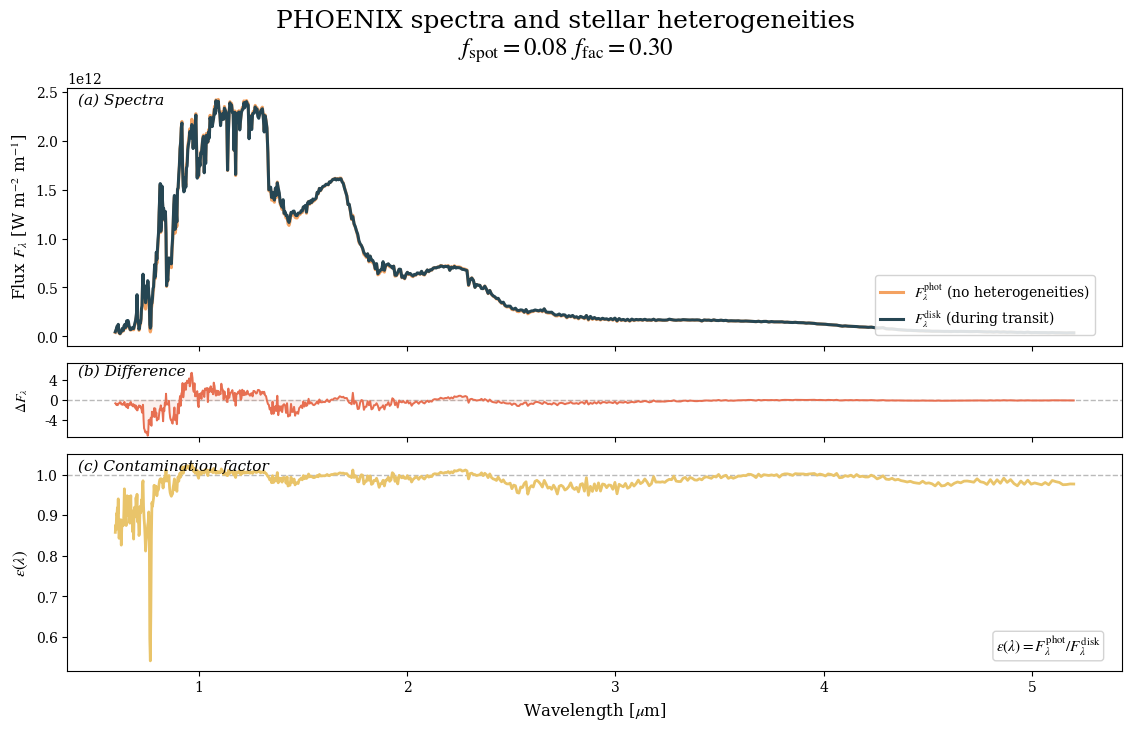

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",
    "sand": "#E9C46A",
    "apricot": "#F4A261",
    "tomato": "#E76F51",
}

diff_abs = F_phot_phx - Fdisk_phx

fig = plt.figure(figsize=(11.2, 7.2), layout="constrained")
gs  = fig.add_gridspec(3, 1, height_ratios=[3.1, 0.9, 2.6], hspace=0.05)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax2 = fig.add_subplot(gs[2], sharex=ax0)

# (a) Espectros
l1, = ax0.plot(wl_plot, F_phot_phx, color=PALETTE["apricot"], lw=2.2,
               label=r"$F_{\lambda}^{\mathrm{phot}}$ (no heterogeneities)")
l2, = ax0.plot(wl_plot, Fdisk_phx,  color=PALETTE["ink"],  lw=2.2,
               label=r"$F_{\lambda}^{\mathrm{disk}}$ (during transit)")
ax0.set_ylabel(r"Flux $F_{\lambda}$ [W m$^{-2}$ m$^{-1}$]", fontsize=12)
ax0.tick_params(labelbottom=False)
ax0.text(0.01, 0.98, "(a) Spectra", transform=ax0.transAxes,
         ha="left", va="top", fontsize=11, fontstyle="italic")

# leyenda adentro, abajo-derecha
leg = ax0.legend(loc="lower right", bbox_to_anchor=(0.98, 0.02),
                 frameon=True, framealpha=0.85, fancybox=True,
                 borderaxespad=0.4, handlelength=1.6)
leg.get_frame().set_edgecolor("0.8")

# (b) ΔF centrado en 0
ax1.axhline(0, color="0.55", ls="--", lw=1, alpha=0.6, zorder=0)
ax1.plot(wl_plot, diff_abs, color=PALETTE["tomato"], lw=1.4, zorder=2)
ax1.fill_between(wl_plot, 0, diff_abs, color=PALETTE["tomato"], alpha=0.10, zorder=1)
m = np.nanmax(np.abs(diff_abs))
if np.isfinite(m) and m > 0:
    ax1.set_ylim(-1.05*m, 1.05*m)
ax1.yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
ax1.tick_params(labelbottom=False)
ax1.text(0.01, 0.98, "(b) Difference", transform=ax1.transAxes,
         ha="left", va="top", fontsize=11, fontstyle="italic")

# mover el 1eX del offset a la etiqueta del eje
fig.canvas.draw()
offset_txt = ax1.yaxis.get_offset_text().get_text()
if offset_txt:
    exp = offset_txt.replace('1e', '')
    ax1.set_ylabel(r"$\Delta F_{\lambda}$")
    ax1.yaxis.get_offset_text().set_visible(False)
else:
    ax1.set_ylabel(r"$\Delta F_{\lambda}$ [W m$^{-2}$ m$^{-1}$]",fontsize=12)

# (c) epsilon
ax2.axhline(1, color="0.55", ls="--", lw=1, alpha=0.6)
ax2.plot(wl_plot, eps_phx, color=PALETTE["sand"], lw=2.0)
ax2.set_xlabel(r"Wavelength [$\mu$m]", fontsize=12)
ax2.set_ylabel(r"$\epsilon(\lambda)$", fontsize=12)
ax2.text(0.01, 0.98, "(c) Contamination factor", transform=ax2.transAxes,
         ha="left", va="top", fontsize=11, fontstyle="italic")

# definición adentro, abajo-derecha (sin tapar la curva)
ax2.annotate(r"$\epsilon(\lambda)=F_{\lambda}^{\mathrm{phot}}/F_{\lambda}^{\mathrm{disk}}$",
             xy=(0.98, 0.06), xycoords='axes fraction',
             ha='right', va='bottom', fontsize=11,
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85, ec='0.8'))

fig.suptitle("PHOENIX spectra and stellar heterogeneities\n$f_\mathrm{spot}= 0.08$\t$f_\mathrm{fac}= 0.30$", fontsize=18)
fig.align_ylabels([ax0, ax1, ax2])


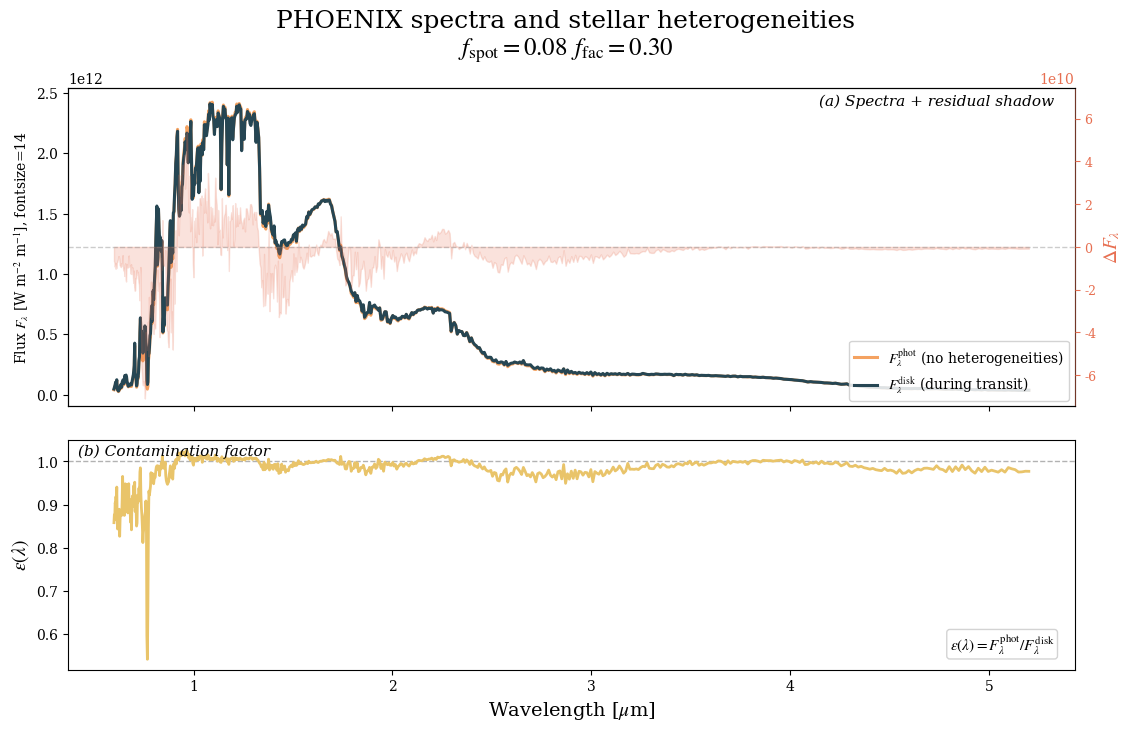

In [ ]:
PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",
    "sand": "#E9C46A",
    "apricot": "#F4A261",
    "tomato": "#E76F51",
}

res = F_phot_phx - Fdisk_phx

fig, ax = plt.subplots(
    2, 1, figsize=(11.2, 7.2), sharex=True,
    gridspec_kw=dict(height_ratios=[3.6, 2.6], hspace=0.08),
    layout="constrained"
)

# (a) Espectros
ax[0].plot(wl_plot, F_phot_phx, color=PALETTE["apricot"], lw=2.2,
           label=r"$F_{\lambda}^{\mathrm{phot}}$ (no heterogeneities)")
ax[0].plot(wl_plot, Fdisk_phx, color=PALETTE["ink"], lw=2.2,
           label=r"$F_{\lambda}^{\mathrm{disk}}$ (during transit)")
ax[0].set_ylabel(r"Flux $F_{\lambda}$ [W m$^{-2}$ m$^{-1}$], fontsize=14")

# Leyenda dentro
leg = ax[0].legend(
    loc="lower right", frameon=True, framealpha=0.85,
    fancybox=True, borderaxespad=0.4, handlelength=1.6
)
leg.get_frame().set_edgecolor("0.8")

# Eje Y secundario solo para escala y sombra
axR = ax[0].twinx()
axR.set_ylabel(r"$\Delta F_{\lambda}$", color=PALETTE["tomato"], fontsize=14)
axR.patch.set_visible(False)

# Línea base
axR.axhline(0, color="0.5", ls="--", lw=1, alpha=0.4, zorder=0)

# Sombra de ΔF detrás de las curvas principales
m = np.nanmax(np.abs(res))
if np.isfinite(m) and m > 0:
    axR.set_ylim(-1.05*m, 1.05*m)
axR.fill_between(wl_plot, 0, res, color=PALETTE["tomato"], alpha=0.20, zorder=-1)

# Eje derecho discreto
axR.spines["right"].set_color(PALETTE["tomato"])
axR.spines["right"].set_alpha(0.5)
axR.tick_params(axis="y", colors=PALETTE["tomato"], labelsize=9)

ax[0].text(0.98, 0.98, "(a) Spectra + residual shadow", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=11, fontstyle="italic")

# (b) Contamination factor
ax[1].axhline(1, color="0.5", ls="--", lw=1, alpha=0.6)
ax[1].plot(wl_plot, eps_phx, color=PALETTE["sand"], lw=2.0)
ax[1].set_xlabel(r"Wavelength [$\mu$m]", fontsize=14)
ax[1].set_ylabel(r"$\epsilon(\lambda)$", fontsize=14)
ax[1].text(0.01, 0.98, "(b) Contamination factor", transform=ax[1].transAxes,
           ha="left", va="top", fontsize=11, fontstyle="italic")

# Definición dentro
ax[1].annotate(r"$\epsilon(\lambda)=F_{\lambda}^{\mathrm{phot}}/F_{\lambda}^{\mathrm{disk}}$",
               xy=(0.98, 0.06), xycoords='axes fraction',
               ha='right', va='bottom', fontsize=11,
               bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85, ec='0.8'))

fig.suptitle("PHOENIX spectra and stellar heterogeneities\n$f_\mathrm{spot}= 0.08$\t$f_\mathrm{fac}= 0.30$", fontsize=18)
fig.align_ylabels(ax)
plt.savefig("PHOENIX_spectrum.png", dpi = 300)

##### Stellar Contam

In [ ]:
phx_star_cont = create_star(
    R_s, T_s, log_g_s, Met_s,
    stellar_grid="phoenix",
    stellar_contam="two_spots",
    f_spot=0.08, T_spot=0.86 * T_s,
    f_fac=0.30, T_fac=T_s + 100,
    wl=wl
    # interp_backend="pysynphot",  # descomenta si usas pysynphot para phoenix
)

# Estrella sin heterogeneidades (pasa wl=wl)
phx_star_uncont = create_star(
    R_s, T_s, log_g_s, Met_s,
    stellar_grid="phoenix",
    wl=wl
)

In [ ]:
planet = create_planet(planet_name, R_p, gravity=g_p, T_eq=T_eq)

bulk_species  = ['N2']
param_species = ['H2O', 'CH4', 'CO2', 'O3', 'N2O']

phx_model_cont = define_model(
    "phx cont", bulk_species, param_species,
    PT_profile='isotherm', cloud_model='cloud-free',
    stellar_contam="two_spots"
    )

P_min, P_max, N_layers = 1e-5, 1.0, 100
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)
P_ref  = 1.0
R_p_ref = R_p
PT_params    = np.array([200.0])  # K
log_X_params = np.array([-4.82, -5.46, -2.93, -5.43, -6.64])  # orden = param_species

phx_atm = make_atmosphere(planet, phx_model_cont, P, P_ref, R_p_ref, PT_params, log_X_params)

opacity_treatment = 'opacity_sampling'

T_fine_min, T_fine_max, T_fine_step = 200, 400, 10
T_fine = np.arange(T_fine_min, T_fine_max + T_fine_step, T_fine_step)

log_P_fine_min, log_P_fine_max, log_P_fine_step = -6.0, 2.0, 0.2
log_P_fine = np.arange(log_P_fine_min, log_P_fine_max + log_P_fine_step, log_P_fine_step)

opac = read_opacities(phx_model_cont, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
O3 done
N2O done
Opacity pre-interpolation complete.


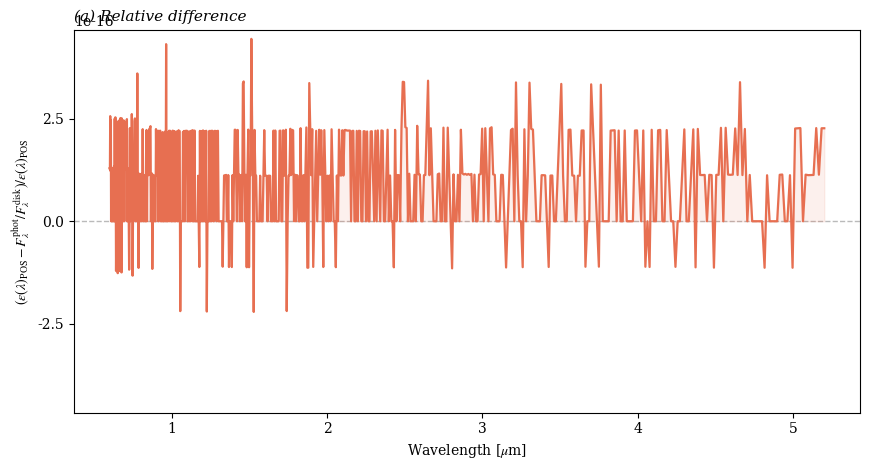

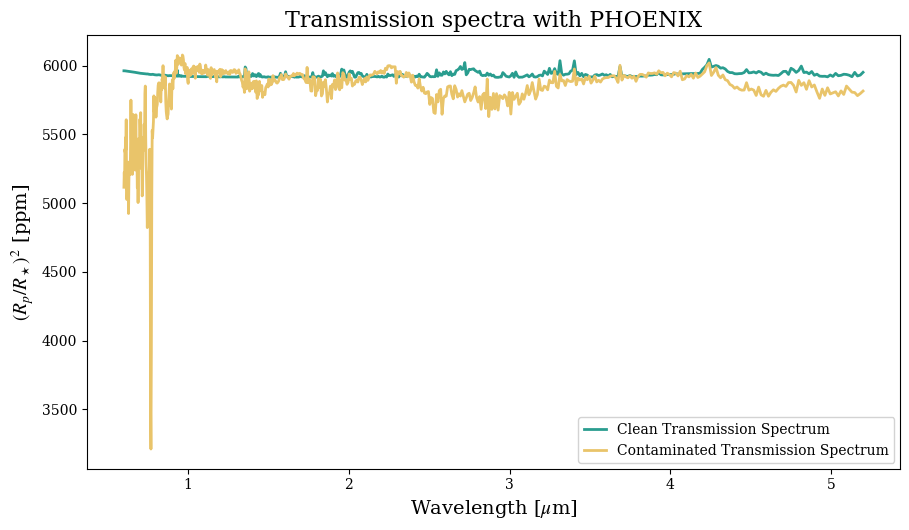

In [ ]:
# --- Preparar datos ---
phx_tm = compute_spectrum(
    planet, phx_star_cont, phx_model_cont, phx_atm, opac, wl,
    spectrum_type='transmission'
)
from POSEIDON.stellar import stellar_contamination
POS_eps_phx = stellar_contamination(phx_star_cont, wl)

# Evitar divisiones por cero o NaN en la diferencia relativa
den = POS_eps_phx
safe = np.isfinite(den) & (den != 0)
rel_diff = np.full_like(den, np.nan, dtype=float)
rel_diff[safe] = (POS_eps_phx[safe] - eps_phx[safe]) / den[safe]

tm_clean = phx_tm
tm_cont  = phx_tm * POS_eps_phx

# =========================
# FIGURA 1: Diferencia relativa de epsilon (un solo eje)
# =========================
plt.figure(figsize=(8.8, 4.8))
plt.axhline(0, color="0.55", ls="--", lw=1, alpha=0.6, zorder=0)
plt.plot(wl, rel_diff, color=PALETTE["tomato"], lw=1.6, zorder=2)
plt.fill_between(wl, 0, rel_diff, color=PALETTE["tomato"], alpha=0.10, zorder=1)

m = np.nanmax(np.abs(rel_diff))
if np.isfinite(m) and m > 0:
    plt.ylim(-1.05*m, 1.05*m)

plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))

# Etiqueta con división usando "/" (más legible)
plt.ylabel(r"$(\epsilon(\lambda)_{\mathrm{POS}} - F_{\lambda}^{\mathrm{phot}} / F_{\lambda}^{\mathrm{disk}}) / \epsilon(\lambda)_{\mathrm{POS}}$")
plt.xlabel(r"Wavelength [$\mu$m]")
plt.title("(a) Relative difference", loc="left", fontstyle="italic", fontsize=11)

plt.tight_layout()
plt.show()

# =========================
# FIGURA 2: Transmisión limpia vs. contaminada en ppm
# =========================
plt.figure(figsize=(9.2, 5.4))

plt.plot(wl, tm_clean * 1e6, lw=2.0, color=PALETTE["teal"], 
 label="Clean Transmission Spectrum")
plt.plot(wl, tm_cont  * 1e6, lw=2.0, color=PALETTE["sand"],
 label="Contaminated Transmission Spectrum")

plt.xlabel(r"Wavelength [$\mu$m]", fontsize=14)
plt.ylabel(r"$(R_p/R_\star)^2$ [ppm]", fontsize=14)
plt.title("Transmission spectra with PHOENIX", fontsize=16)

# Leyenda arriba-derecha
leg = plt.legend(frameon=True, framealpha=0.85, fancybox=True,
                 borderaxespad=0.4, handlelength=1.6)
leg.get_frame().set_edgecolor("0.8")

plt.tight_layout()

plt.savefig("TLSE_PHOENIX.png", dpi = 300)
plt.show()

### SPHINX

#### Spectra

In [ ]:
# ===========================================
# Funciones SPHINX: indexado + interp. lineal en Teff
# ===========================================
import re
from pathlib import Path
import numpy as np

# --- 1) Patrón de nombres ---
# Ej.: "Teff_2600.0_logg_5.25_logZ_+0.0_CtoO_0.5.txt"
# Captura Teff (T), logg (g), logZ (Z), C/O (C)
_SPX_PAT = re.compile(
    r"Teff_(?P<T>[0-9]+(?:\.[0-9]+)?)_logg_(?P<g>[0-9]+(?:\.[0-9]+)?)_logZ_(?P<Z>[+\-]?[0-9]+(?:\.[0-9]+)?)_CtoO_(?P<C>[0-9]+(?:\.[0-9]+)?)",
    re.I
)

def build_sphinx_index(dirpath: Path):
    """
    Recorre la carpeta 'dirpath' y crea un índice:
        IDX[(Teff, logg, logZ, CtoO)] = 'ruta/al/archivo'
    - Usa un regex robusto (_SPX_PAT) para extraer los metadatos desde el nombre.
    - Admite cualquier extensión (p.ej. .txt/.dat), siempre que cumpla el patrón.
    - Lanza RuntimeError si no encuentra ningún archivo válido.
    """
    out = {}
    files = list(Path(dirpath).glob("*.*"))
    for p in files:
        m = _SPX_PAT.search(p.name.strip())
        if not m:
            continue
        T = float(m.group("T"))
        g = float(m.group("g"))
        Z = float(m.group("Z"))
        C = float(m.group("C"))
        out[(T, g, Z, C)] = str(p)
    if not out:
        raise RuntimeError(f"[SPHINX] No encontré archivos válidos en {dirpath}. Revisa nombres/patrón.")
    return out

def load_two_col_txt(path, wl_col=0, F_col=1):
    """
    Lee un archivo de dos columnas:
      - wl_col: columna de longitud de onda (se asume μm)
      - F_col : columna de flujo espectral Fλ [W m^-2 m^-1]
    Devuelve:
      wl (ordenado en ascendente) y F (positivo, sin NaN) como np.array.
    """
    wl, F = [], []
    with open(path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = s.split()
            wl.append(float(parts[wl_col])); F.append(float(parts[F_col]))
    wl = np.asarray(wl, float); F = np.asarray(F, float)

    # Filtra valores no numéricos y no positivos
    ok = np.isfinite(wl) & np.isfinite(F) & (F > 0)
    wl, F = wl[ok], F[ok]

    # Ordena por λ (por si el archivo no viene ordenado)
    s = np.argsort(wl)
    return wl[s], F[s]

def regrid_linear(wl_src, F_src, wl_tgt):
    """
    Regrilla F(λ) desde wl_src → wl_tgt por interpolación lineal.
    - Rellena bordes por 'nearest' (valor más cercano).
    - Asegura F > 0 y elimina posibles NaN residuales.
    """
    F = np.interp(wl_tgt, wl_src, F_src, left=np.nan, right=np.nan)

    # Bordes: nearest
    if np.isnan(F[0]):
        i0 = np.flatnonzero(~np.isnan(F))
        if i0.size: F[:i0[0]] = F[i0[0]]
    if np.isnan(F[-1]):
        i1 = np.flatnonzero(~np.isnan(F))
        if i1.size: F[i1[-1]+1:] = F[i1[-1]]

    # Seguridad: positividad y NaN
    if np.any(F <= 0):
        pos = F[F > 0]
        F[F <= 0] = (np.min(pos) if pos.size else 1.0) * 1e-12
    if np.isnan(F).any():
        good = ~np.isnan(F)
        F = np.interp(wl_tgt, wl_tgt[good], F[good])

    return F

def available_T(idx: dict, logg, logZ, CtoO,
                atol_g=1e-2, atol_Z=1e-6, atol_C=5e-3):
    """
    Devuelve el array de Teff disponibles en el índice 'idx' que coinciden
    (dentro de tolerancias) con (logg, logZ, CtoO).
    Útil para saber qué nodos en Teff se pueden usar para la interpolación.
    """
    Ts = []
    for (T, g, Z, C), _ in idx.items():
        if np.isclose(g, logg, atol=atol_g) and np.isclose(Z, logZ, atol=atol_Z) and np.isclose(C, CtoO, atol=atol_C):
            Ts.append(T)
    return np.array(sorted(set(Ts)), float)

def load_exact_on_wl(idx: dict, Teff, logg, logZ, CtoO, wl,
                     atol_T=1e-6, atol_g=1e-2, atol_Z=1e-6, atol_C=5e-3):
    """
    Carga un nodo EXACTO (Teff, logg, logZ, CtoO) si existe en 'idx'
    (con tolerancias) y lo regrilla a 'wl'.
    Devuelve F(wl) o None si no existe ese nodo.
    """
    for (T, g, Z, C), path in idx.items():
        if (np.isclose(T, Teff, atol=atol_T) and
            np.isclose(g, logg, atol=atol_g) and
            np.isclose(Z, logZ, atol=atol_Z) and
            np.isclose(C, CtoO, atol=atol_C)):
            wl_raw, F_raw = load_two_col_txt(path)
            return regrid_linear(wl_raw, F_raw, wl)
    return None

def interp_T_on_wl(idx: dict, Teff_target, logg, logZ, CtoO, wl,
                   clamp='nearest',
                   atol_g=1e-2, atol_Z=1e-6, atol_C=5e-3):
    """
    Interpolación LINEAL en Teff (manteniendo logg, Z, C/O fijos).
    Pasos:
      1) Busca todos los Teff disponibles con ese (logg, Z, C/O).
      2) Si existe el nodo exacto, lo usa.
      3) Si Teff_target está fuera de rango:
         - si clamp='nearest', usa el borde más cercano (sin extrapolar),
         - de lo contrario, lanza ValueError.
      4) Si está entre dos Teff, interpola LINEALMENTE en FLUJO:
         F(λ; T) = (1-w) F(λ; T_lo) + w F(λ; T_hi), con w en [0,1].
    Devuelve:
      F_interp(wl), T_lo, T_hi  (los nodos de Teff usados).
    """
    Ts = available_T(idx, logg, logZ, CtoO, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
    if Ts.size == 0:
        raise RuntimeError("No hay espectros SPHINX para ese (logg, [M/H], C/O). Revisa la carpeta o las tolerancias.")

    # 2) Nodo exacto en Teff
    F_exact = load_exact_on_wl(idx, Teff_target, logg, logZ, CtoO, wl,
                               atol_T=1e-6, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
    if F_exact is not None:
        return F_exact, Teff_target, Teff_target

    # 3) Fuera de rango → clamp o error
    if Teff_target < Ts[0]:
        if clamp == 'nearest':
            F = load_exact_on_wl(idx, Ts[0], logg, logZ, CtoO, wl,
                                 atol_T=1e-9, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
            return F, Ts[0], Ts[0]
        raise ValueError(f"Teff_target={Teff_target} < Teff_min={Ts[0]}")
    if Teff_target > Ts[-1]:
        if clamp == 'nearest':
            F = load_exact_on_wl(idx, Ts[-1], logg, logZ, CtoO, wl,
                                 atol_T=1e-9, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
            return F, Ts[-1], Ts[-1]
        raise ValueError(f"Teff_target={Teff_target} > Teff_max={Ts[-1]}")

    # 4) Bracketing e interpolación lineal en Fλ
    hi = np.searchsorted(Ts, Teff_target, side='right')
    T_lo, T_hi = Ts[hi-1], Ts[hi]
    F_lo = load_exact_on_wl(idx, T_lo, logg, logZ, CtoO, wl,
                            atol_T=1e-9, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
    F_hi = load_exact_on_wl(idx, T_hi, logg, logZ, CtoO, wl,
                            atol_T=1e-9, atol_g=atol_g, atol_Z=atol_Z, atol_C=atol_C)
    # Peso lineal
    w = (Teff_target - T_lo) / (T_hi - T_lo) if T_hi != T_lo else 0.0
    F = (1.0 - w) * F_lo + w * F_hi
    return F, T_lo, T_hi


In [ ]:
SPHINX_DIR = Path("")     
log_g_s    = 5.25
Met_s      = 0.0
CtoO       = 0.5

IDX = build_sphinx_index(SPHINX_DIR)

# --- 2) Interpola linealmente en Teff (logg, Z, C/O fijos) ---
F_phot_sph, Tlo_p, Thi_p = interp_T_on_wl(IDX, T_s,       log_g_s, Met_s, CtoO, wl_plot, clamp='nearest')
F_spot_sph, Tlo_s, Thi_s = interp_T_on_wl(IDX, T_spot,    log_g_s, Met_s, CtoO, wl_plot, clamp='nearest')
F_facA_sph, Tlo_f, Thi_f = interp_T_on_wl(IDX, T_fac,     log_g_s, Met_s, CtoO, wl_plot, clamp='nearest')

# --- 3) Mezcla del disco y ε(λ) ---
Fdisk_sph = f_q*F_phot_sph + f_spot*F_spot_sph + f_fac*F_facA_sph   # Fλ [W m^-2 m^-1]
eps_sph   = F_phot_sph / Fdisk_sph                                  # adimensional

In [ ]:
Tlo_s, Thi_s

(2200.0, 2300.0)

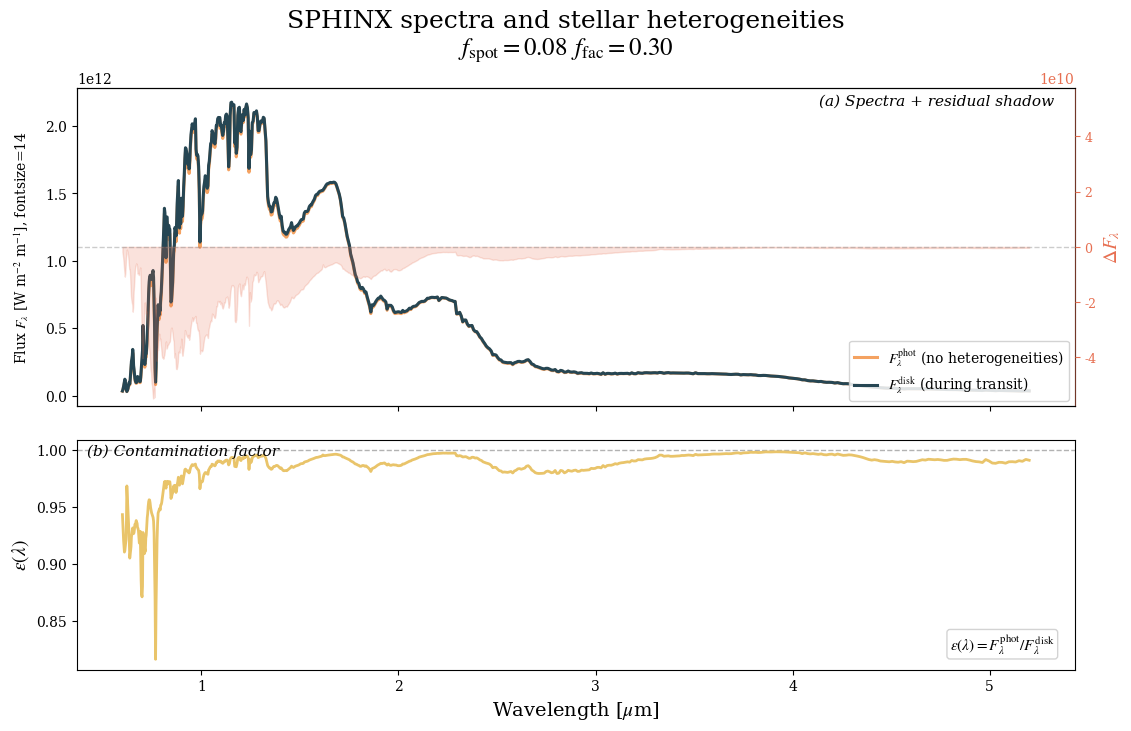

In [ ]:
PALETTE = {
    "ink": "#264653",
    "teal": "#2A9D8F",
    "sand": "#E9C46A",
    "apricot": "#F4A261",
    "tomato": "#E76F51",
}

res = F_phot_sph - Fdisk_sph

fig, ax = plt.subplots(
    2, 1, figsize=(11.2, 7.2), sharex=True,
    gridspec_kw=dict(height_ratios=[3.6, 2.6], hspace=0.08),
    layout="constrained"
)

# (a) Espectros
ax[0].plot(wl_plot, F_phot_sph, color=PALETTE["apricot"], lw=2.2,
           label=r"$F_{\lambda}^{\mathrm{phot}}$ (no heterogeneities)")
ax[0].plot(wl_plot, Fdisk_sph, color=PALETTE["ink"], lw=2.2,
           label=r"$F_{\lambda}^{\mathrm{disk}}$ (during transit)")
ax[0].set_ylabel(r"Flux $F_{\lambda}$ [W m$^{-2}$ m$^{-1}$], fontsize=14")

# Leyenda dentro
leg = ax[0].legend(
    loc="lower right", frameon=True, framealpha=0.85,
    fancybox=True, borderaxespad=0.4, handlelength=1.6
)
leg.get_frame().set_edgecolor("0.8")

# Eje Y secundario solo para escala y sombra
axR = ax[0].twinx()
axR.set_ylabel(r"$\Delta F_{\lambda}$", color=PALETTE["tomato"], fontsize=14)
axR.patch.set_visible(False)

# Línea base
axR.axhline(0, color="0.5", ls="--", lw=1, alpha=0.4, zorder=0)

# Sombra de ΔF detrás de las curvas principales
m = np.nanmax(np.abs(res))
if np.isfinite(m) and m > 0:
    axR.set_ylim(-1.05*m, 1.05*m)
axR.fill_between(wl_plot, 0, res, color=PALETTE["tomato"], alpha=0.20, zorder=-1)

# Eje derecho discreto
axR.spines["right"].set_color(PALETTE["tomato"])
axR.spines["right"].set_alpha(0.5)
axR.tick_params(axis="y", colors=PALETTE["tomato"], labelsize=9)

ax[0].text(0.98, 0.98, "(a) Spectra + residual shadow", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=11, fontstyle="italic")

# (b) Contamination factor
ax[1].axhline(1, color="0.5", ls="--", lw=1, alpha=0.6)
ax[1].plot(wl_plot, eps_sph, color=PALETTE["sand"], lw=2.0)
ax[1].set_xlabel(r"Wavelength [$\mu$m]", fontsize=14)
ax[1].set_ylabel(r"$\epsilon(\lambda)$", fontsize=14)
ax[1].text(0.01, 0.98, "(b) Contamination factor", transform=ax[1].transAxes,
           ha="left", va="top", fontsize=11, fontstyle="italic")

# Definición dentro
ax[1].annotate(r"$\epsilon(\lambda)=F_{\lambda}^{\mathrm{phot}}/F_{\lambda}^{\mathrm{disk}}$",
               xy=(0.98, 0.06), xycoords='axes fraction',
               ha='right', va='bottom', fontsize=11,
               bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85, ec='0.8'))

fig.suptitle("SPHINX spectra and stellar heterogeneities\n$f_\mathrm{spot}= 0.08$\t$f_\mathrm{fac}= 0.30$", fontsize=18)
fig.align_ylabels(ax)

plt.savefig("SPHINX_spectrum.png", dpi = 300)


#### Stellar Contam

In [ ]:
sph_star_cont = create_star(
    R_s, T_s, log_g_s, Met_s,
    stellar_grid="custom",
    user_wl=wl,                 # μm
    user_spectrum=F_phot_sph,   # Fλ [W m^-2 m^-1] a esa wl
    wl=wl,
)



In [ ]:
sph_model_cont = define_model(
    "sph cont", bulk_species, param_species,
    PT_profile='isotherm', cloud_model='cloud-free',
    stellar_contam="two_spots"
    )


sph_atm = make_atmosphere(planet, sph_model_cont, P, P_ref, R_p_ref, PT_params, log_X_params)

opacity_treatment = 'opacity_sampling'

T_fine_min, T_fine_max, T_fine_step = 200, 400, 10
T_fine = np.arange(T_fine_min, T_fine_max + T_fine_step, T_fine_step)

log_P_fine_min, log_P_fine_max, log_P_fine_step = -6.0, 2.0, 0.2
log_P_fine = np.arange(log_P_fine_min, log_P_fine_max + log_P_fine_step, log_P_fine_step)

opac = read_opacities(sph_model_cont, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
CO2-CO2 done
CO2-CH4 done
N2-N2 done
N2-H2O done
H2O done
CH4 done
CO2 done
O3 done
N2O done
Opacity pre-interpolation complete.


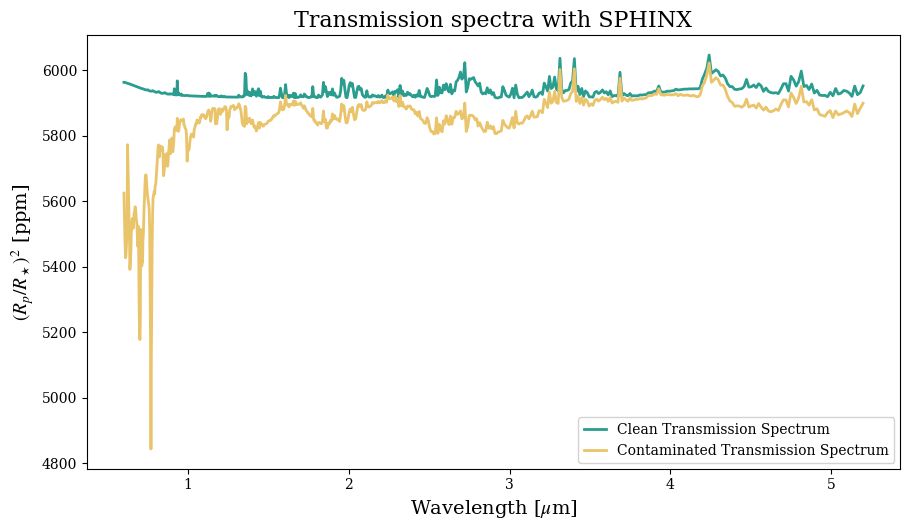

In [ ]:
# --- Preparar datos ---
sph_tm = compute_spectrum(
    planet, sph_star_cont, sph_model_cont, sph_atm, opac, wl,
    spectrum_type='transmission'
)


tm_clean = sph_tm
tm_cont  = sph_tm * eps_sph


# =========================
# FIGURA 2: Transmisión limpia vs. contaminada en ppm
# =========================
plt.figure(figsize=(9.2, 5.4))

plt.plot(wl, tm_clean * 1e6, lw=2.0, color=PALETTE["teal"], 
 label="Clean Transmission Spectrum")
plt.plot(wl, tm_cont  * 1e6, lw=2.0, color=PALETTE["sand"],
 label="Contaminated Transmission Spectrum")

plt.xlabel(r"Wavelength [$\mu$m]", fontsize=14)
plt.ylabel(r"$(R_p/R_\star)^2$ [ppm]", fontsize=14)
plt.title("Transmission spectra with SPHINX", fontsize=16)

# Leyenda arriba-derecha
leg = plt.legend(frameon=True, framealpha=0.85, fancybox=True,
                 borderaxespad=0.4, handlelength=1.6)
leg.get_frame().set_edgecolor("0.8")

plt.tight_layout()
plt.savefig("TLSE_SPHINX.png", dpi = 300)
plt.show()

### Final plots

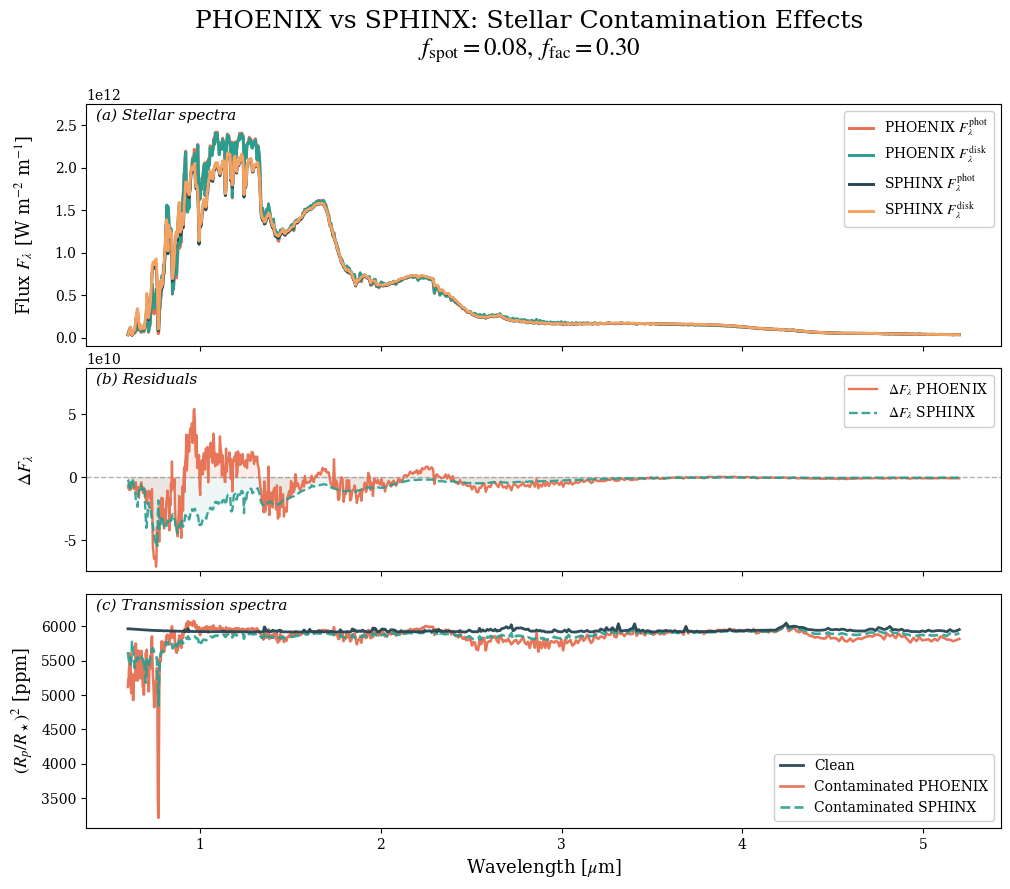

In [ ]:
# ===== Colores de la paleta =====
C_PHX_RES  = PALETTE["tomato"]  # naranjoso PHOENIX
C_SPH_RES  = PALETTE["teal"]     # verdoso SPHINX
C_CLEAN    = PALETTE["ink"]      # azul oscuro para transmisión limpia

# Subplot 1: el mismo esquema que dijiste que estaba bien
C_PHX_PHOT = PALETTE["tomato"]
C_PHX_DISK = PALETTE["teal"]
C_SPH_PHOT = PALETTE["ink"]
C_SPH_DISK = PALETTE["apricot"]

# Eje X común
wl_x = wl

# Residuos
res_phx = F_phot_phx - Fdisk_phx
res_sph = F_phot_sph - Fdisk_sph

# Transmisiones
tm_clean    = sph_tm
tm_cont_phx = tm_clean * eps_phx
tm_cont_sph = tm_clean * eps_sph

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(
    3, 1, figsize=(11.8, 9.4), sharex=True,
    gridspec_kw=dict(height_ratios=[3.1, 2.6, 3.0], hspace=0.10)
)


# -----------------------------
# (a) Stellar spectra (phot/disk diferenciados por grilla)
# -----------------------------
ax[0].plot(wl_x, F_phot_phx, lw=2.1, color=C_PHX_PHOT, alpha=1,
           label=r"PHOENIX $F_{\lambda}^{\rm phot}$")
ax[0].plot(wl_x, Fdisk_phx, lw=2.1, color=C_PHX_DISK, alpha=1,
           label=r"PHOENIX $F_{\lambda}^{\rm disk}$")

ax[0].plot(wl_x, F_phot_sph, lw=2.1, color=C_SPH_PHOT, alpha=1,
           label=r"SPHINX $F_{\lambda}^{\rm phot}$")
ax[0].plot(wl_x, Fdisk_sph, lw=2.1, color=C_SPH_DISK, alpha=1,
           label=r"SPHINX $F_{\lambda}^{\rm disk}$")

ax[0].set_ylabel(r"Flux $F_{\lambda}$ [W m$^{-2}$ m$^{-1}$]", fontsize=13)
ax[0].text(0.01, 0.98, "(a) Stellar spectra", transform=ax[0].transAxes,
           ha="left", va="top", fontsize=11, fontstyle="italic")

leg0 = ax[0].legend(
    frameon=True, framealpha=0.95, fancybox=True, ncol=1,
    borderaxespad=0.5, handlelength=1.7
)
leg0.get_frame().set_edgecolor("0.8")

# -----------------------------
# (b) Residuals (PHX naranjoso, SPH verdoso)
# -----------------------------
ax[1].axhline(0, color="0.5", ls="--", lw=1, alpha=0.6, zorder=0)

# PHOENIX
ax[1].plot(wl_x, res_phx, lw=1.7, color=C_PHX_RES, alpha=0.95,
           label=r"$\Delta F_{\lambda}$ PHOENIX")
ax[1].fill_between(wl_x, 0, res_phx, color=C_PHX_RES, alpha=0.12)

# SPHINX
ax[1].plot(wl_x, res_sph, lw=1.7, color=C_SPH_RES, alpha=0.9, ls="--",
           label=r"$\Delta F_{\lambda}$ SPHINX")
ax[1].fill_between(wl_x, 0, res_sph, color=C_SPH_RES, alpha=0.08)

m = np.nanmax(np.abs(np.concatenate([res_phx, res_sph])))
if np.isfinite(m) and m > 0:
    ax[1].set_ylim(-1.05*m, 1.05*m)

ax[1].yaxis.set_major_locator(MaxNLocator(nbins=4, prune="both"))
ax[1].set_ylabel(r"$\Delta F_{\lambda}$", fontsize=13)
ax[1].text(0.01, 0.98, "(b) Residuals", transform=ax[1].transAxes,
           ha="left", va="top", fontsize=11, fontstyle="italic")

leg1 = ax[1].legend(
        frameon=True, framealpha=0.95, fancybox=True
)
leg1.get_frame().set_edgecolor("0.8")

# -----------------------------
# (c) Transmission spectra (PHX naranjoso, SPH verdoso, clean ink)
# -----------------------------
ax[2].plot(wl_x, tm_clean*1e6, lw=2.0, color=C_CLEAN, alpha=0.96,
           label="Clean", zorder=3)
ax[2].plot(wl_x, tm_cont_phx*1e6, lw=1.9, color=C_PHX_RES, alpha=0.95,
           label="Contaminated PHOENIX")
ax[2].plot(wl_x, tm_cont_sph*1e6, lw=1.9, color=C_SPH_RES, alpha=0.9, ls="--",
           label="Contaminated SPHINX")

ax[2].set_xlabel(r"Wavelength [$\mu$m]", fontsize=13)
ax[2].set_ylabel(r"$(R_p/R_\star)^2$ [ppm]", fontsize=13)
ax[2].text(0.01, 0.98, "(c) Transmission spectra", transform=ax[2].transAxes,
           ha="left", va="top", fontsize=11, fontstyle="italic")

leg2 = ax[2].legend(
    loc="lower right", frameon=True, framealpha=0.96, fancybox=True,
    borderaxespad=0.5, handlelength=1.7
)
leg2.get_frame().set_edgecolor("0.8")
leg2.get_frame().set_facecolor("white")


# Para subplot (a) y (b) y (c) que tienen texto en la esquina superior
for idx in [0, 1, 2]:
    ymin, ymax = ax[idx].get_ylim()
    ax[idx].set_ylim(ymin, ymax + 0.08*(ymax - ymin))  # 8% más de margen

# -----------------------------
# Título y layout
# -----------------------------
fig.suptitle(
    r"PHOENIX vs SPHINX: Stellar Contamination Effects" "\n"
    r"$f_{\rm spot}=0.08,\; f_{\rm fac}=0.30$",
    fontsize=18, y=0.98
)
fig.tight_layout(rect=[0.06, 0.045, 0.80, 0.955])
fig.align_ylabels(ax)


plt.savefig("Stellar_contam.png", dpi = 300)
plt.savefig("Stellar_contam.svg", dpi = 300)
plt.show()


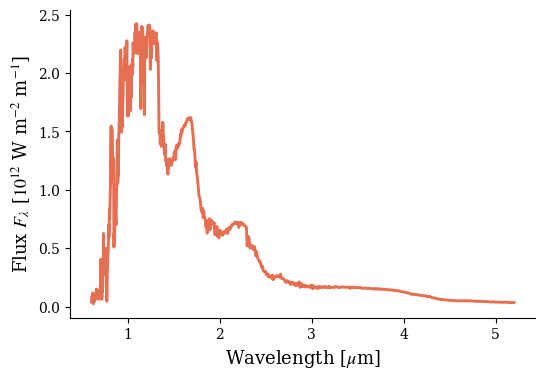

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(wl_x, F_phot_phx/1e12, lw=2.1, color=C_PHX_PHOT, alpha=1,
           label=r"PHOENIX $F_{\lambda}^{\rm phot}$")
plt.ylabel(r"Flux $F_\lambda$ [$10^{12}$ W m$^{-2}$ m$^{-1}$]", fontsize = 13)
plt.xlabel("Wavelength [$\mu$m]", fontsize=13)

# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("Phoenix_spectrum01.svg", dpi=300, transparent=True)

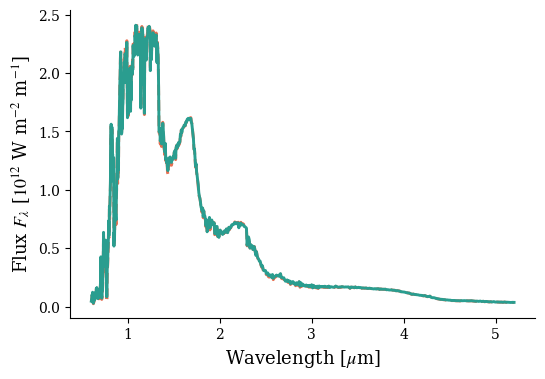

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(wl_x, F_phot_phx/1e12, lw=2.1, color=C_PHX_PHOT, alpha=1,
           ls = "--", label=r"PHOENIX $F_{\lambda}^{\rm phot}$")
plt.plot(wl_x, Fdisk_phx/1e12, lw=2.1, color=C_PHX_DISK,
           label=r"PHOENIX $F_{\lambda}^{\rm disk}$")
plt.ylabel(r"Flux $F_\lambda$ [$10^{12}$ W m$^{-2}$ m$^{-1}$]", fontsize = 13)
plt.xlabel("Wavelength [$\mu$m]", fontsize=13)

# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("PhoenixDisk_spectrum01.svg", dpi=300, transparent=True)

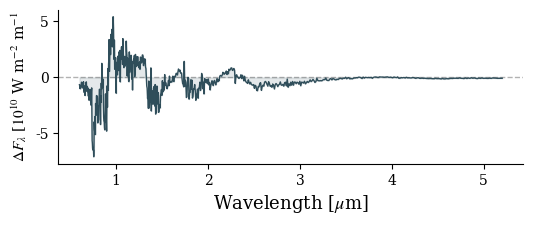

In [ ]:
plt.figure(figsize= (6,2))
plt.axhline(0, color="0.5", ls="--", lw=1, alpha=0.6, zorder=0)

# PHOENIX
plt.plot(wl_x, res_phx/1e10, lw=1, color=C_SPH_PHOT, alpha=0.95,
           label=r"$\Delta F_{\lambda}$ PHOENIX")
plt.fill_between(wl_x, 0, res_phx/1e10, color=C_SPH_PHOT, alpha=0.12)
plt.xlabel("Wavelength [$\mu$m]", fontsize=13)

plt.ylabel(r"$\Delta F_{\lambda}$ [$10^{10}$ W m$^{-2}$ m$^{-1}$", fontsize=11)

# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("Phoenix_Deltaspectrum01.svg", dpi=300, transparent=True)

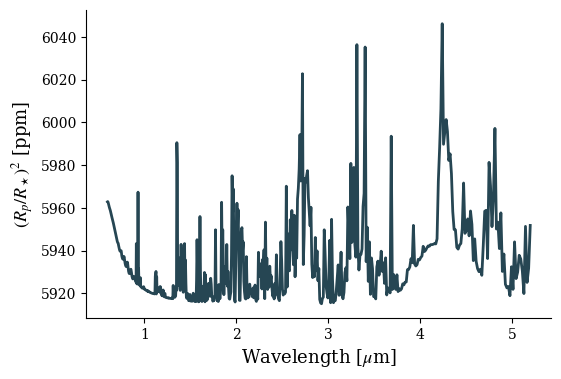

In [ ]:
plt.figure(figsize= (6,4))
plt.plot(wl_x, tm_clean*1e6, lw=2.0, color=C_CLEAN,
           label="Clean")
plt.ylabel(r"$(R_p/R_\star)^2$ [ppm]", fontsize=13)
plt.xlabel("Wavelength [$\mu$m]", fontsize=13)
# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("Transit_spectrum01.svg", dpi=300, transparent=True)

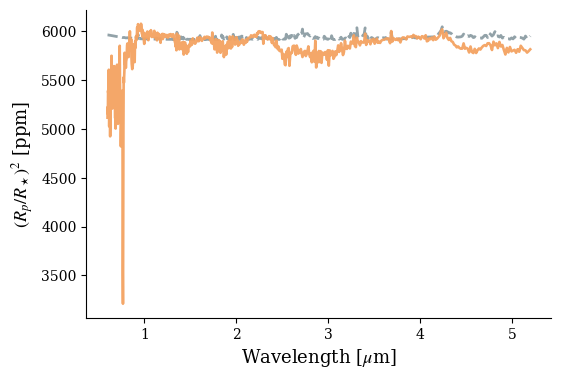

In [ ]:
plt.figure(figsize= (6,4))
plt.plot(wl_x, tm_clean*1e6, lw=2.0, color=C_CLEAN, alpha=0.5,
           label="Clean", ls = "--")
plt.plot(wl_x, tm_cont_phx*1e6, lw=1.9, color=C_SPH_DISK, alpha=0.95,
           label="Contaminated PHOENIX")
plt.ylabel(r"$(R_p/R_\star)^2$ [ppm]", fontsize=13)
plt.xlabel("Wavelength [$\mu$m]", fontsize=13)

# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("TransitDisk_spectrum01.svg", dpi=300, transparent=True)

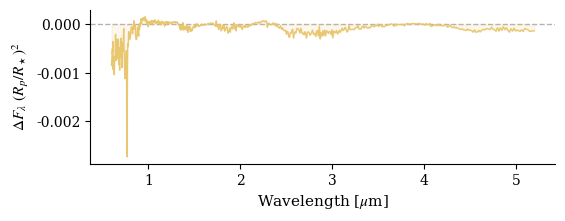

In [ ]:
plt.figure(figsize= (6,2))
tm_res = tm_cont_phx - tm_clean
plt.axhline(0, color="0.5", ls="--", lw=1, alpha=0.6, zorder=0)

# PHOENIX
plt.plot(wl_x, tm_res, lw=1, color=PALETTE["sand"], alpha=0.95,
           label=r"$\Delta F_{\lambda}$ PHOENIX")
plt.fill_between(wl_x, 0, tm_res, color=PALETTE["sand"], alpha=0.12)
plt.xlabel("Wavelength [$\mu$m]", fontsize=11)

plt.ylabel(r"$\Delta (R_p/R_\star)^2$", fontsize=11)

# Obtener los ejes actuales
ax = plt.gca()

# Ocultar los ejes superior y derecho
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Guardar la figura con fondo transparente
plt.savefig("TransitDelta_spectrum01.svg", dpi=300, transparent=True)